¡Hola Ricardo! Espero estés bien.

Mi nombre es **Gina Buvoli**. Un gusto conocerte, seré tu revisora en este proyecto.

A continuación, te comparto un poco sobre la modalidad de revisión que vamos a usar:

Cuando encuentre un error por primera vez, simplemente lo señalaré y dejaré que lo detectes y corrijas por tu cuenta. Además, a lo largo del proyecto iré haciendo algunas observaciones para mejorar tu código, así como comentarios sobre tus conclusiones o percepciones sobre el tema.

Si en algún momento no logras resolver la tarea, en la siguiente iteración te daré una pista más precisa, junto con algunos ejemplos prácticos. También estoy abierta a responder cualquier duda que tengas.

Encontrarás mis comentarios a continuación: por favor, no los muevas, modifiques ni elimines.

---

### Formato de Comentarios

Revisaré cuidadosamente cada implementación en tu notebook para asegurar que cumpla con los requisitos y te daré comentarios de acuerdo al siguiente formato:

<div class="alert alert-block alert-success">

<b>Comentario de la revisora [#° iteración]</b> <a class="tocSkip"></a><br>

<b>Éxito ✅</b><br>

¡Excelente trabajo! Esta parte está bien implementada y contribuye significativamente al análisis. Continúa aplicando estas buenas prácticas en futuras secciones.

</div>

<div class="alert alert-block alert-warning">

<b>Comentario de la revisora [#° iteración]</b> <a class="tocSkip"></a><br>

<b>Atención ⚠️</b><br>

El código es correcto, pero hay una recomendación de mejora. No bloquea la aprobación, pero vale la pena ajustarlo.

</div>

<div class="alert alert-block alert-danger">

<b>Comentario de la revisora [#° iteración]</b> <a class="tocSkip"></a><br>

<b>A resolver 🔴</b><br>

Aquí hay un error que es necesario corregir para aprobar. Por favor revisa este punto antes de volver a enviar.

</div>

---

En cada revisión recibirás un **Comentario General** que resume los aspectos positivos, las áreas de mejora y los próximos pasos.

También puedes responderme copiando el siguiente bloque si tienes alguna duda:

<div class="alert alert-block alert-info">

<b>Respuesta del estudiante [#° iteración]</b> <a class="tocSkip"></a>

Aquí puedes escribir tu respuesta o pregunta.

</div>

**¡Empecemos!** 🚀


<div class="alert alert-block alert-danger">
<b>Review General. (Iteración 1)</b> <a class="tocSkip"></a><br><br>

¡Hola Ricardo!

Tu proyecto está muy bien desarrollado en la mayor parte del flujo. Preparas los datos, conviertes <code>user_score</code> correctamente, calculas <code>total_sales</code>, justificas un período reciente para 2017, analizas plataformas, géneros, correlaciones, diferencias regionales y completas ambas pruebas de hipótesis con <code>alpha = 0.05</code>.

También destaco el análisis de juegos multiplataforma y la forma en que conectas varios hallazgos con decisiones para la campaña de 2017.

Antes de aprobar el proyecto necesitamos corregir un punto que afecta directamente el análisis regional por clasificación ESRB: los valores ausentes de <code>rating</code> se están reemplazando por <code>RP</code>. Esa etiqueta ya tiene un significado propio dentro de ESRB (“Rating Pending”), por lo que no representa correctamente “sin clasificación conocida”. Como consecuencia, los porcentajes de RP —especialmente el 60.4% que interpretas en Japón— mezclan dos situaciones distintas y no permiten sostener esa conclusión tal como está escrita.

Revisa ese tratamiento, vuelve a ejecutar el análisis ESRB y actualiza únicamente las conclusiones que dependan de esa categoría.

Vas por buen camino, enfócate en este punto y vuelve a enviar el proyecto.
</div>


# Proyecto ICE · Tienda de videojuegos
Queremos determinar qué hace que un videojuego se venda para preparar la campaña del año siguiente.

In [1]:
import scipy.stats as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Datasets/games.csv')

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  str    
 1   Platform         16715 non-null  str    
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  str    
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  str    
 10  Rating           9949 non-null   str    
dtypes: float64(6), str(5)
memory usage: 1.4 MB


- El dataset cuenta con 16715 registros. Las columnas con mayor cantidad de valores ausentes son las de las calificaciones (`critic_score`, `user_score` y `rating`). Le sigue la columna year_of_release, con 269 valores ausentes, que representan solo un 1,6% de los registros. Las columnas name y genre tienen 2 valores ausentes cada una.
 - Sobre el tipo de datos, la columna `year_of_release` es del tipo `float` y debería ser `int`. Para la columna `user_score`, es del tipo `str` y debería ser del tipo `float`. Esta columna en particular tiene valores "tbd", que en la descripción del dataset significa "To Be Determined". En mi caso, voy a tratar estos como vacío y no como `0`, ya que al hacer esto, cambiaría notablemente los resultados e interpretaciones estadísticas.

## Preparación de los datos

In [2]:
# Compruebo que no hayan valores duplicados

df.duplicated().sum()

np.int64(0)

In [3]:
# Convierto los encabezados del dataset a minúsculas

df.columns = df.columns.str.lower()

In [4]:
# Confirmo los valores únicos de la columna user_score

df['user_score'].unique()


<StringArray>
[  '8',   nan, '8.3', '8.5', '6.6', '8.4', '8.6', '7.7', '6.3', '7.4', '8.2',
   '9', '7.9', '8.1', '8.7', '7.1', '3.4', '5.3', '4.8', '3.2', '8.9', '6.4',
 '7.8', '7.5', '2.6', '7.2', '9.2',   '7', '7.3', '4.3', '7.6', '5.7',   '5',
 '9.1', '6.5', 'tbd', '8.8', '6.9', '9.4', '6.8', '6.1', '6.7', '5.4',   '4',
 '4.9', '4.5', '9.3', '6.2', '4.2',   '6', '3.7', '4.1', '5.8', '5.6', '5.5',
 '4.4', '4.6', '5.9', '3.9', '3.1', '2.9', '5.2', '3.3', '4.7', '5.1', '3.5',
 '2.5', '1.9',   '3', '2.7', '2.2',   '2', '9.5', '2.1', '3.6', '2.8', '1.8',
 '3.8',   '0', '1.6', '9.6', '2.4', '1.7', '1.1', '0.3', '1.5', '0.7', '1.2',
 '2.3', '0.5', '1.3', '0.2', '0.6', '1.4', '0.9',   '1', '9.7']
Length: 97, dtype: str

In [5]:
# Cambio el tipo de datos de la columna user_score

df['user_score'] = pd.to_numeric(df['user_score'], errors='coerce')

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  str    
 1   platform         16715 non-null  str    
 2   year_of_release  16446 non-null  float64
 3   genre            16713 non-null  str    
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       7590 non-null   float64
 10  rating           9949 non-null   str    
dtypes: float64(7), str(4)
memory usage: 1.4 MB


El cambio del tipo de datos de la columna `user_score` lo hice porque inicialmente era una columna del tipo texto y si más adelante necesito hacer alguna operación matemática me conviene convertirla en números.

In [6]:
# Cambio el tipo de datos de la columna year_of_release

df['year_of_release'] = df['year_of_release'].astype('Int64')

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  str    
 1   platform         16715 non-null  str    
 2   year_of_release  16446 non-null  Int64  
 3   genre            16713 non-null  str    
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       7590 non-null   float64
 10  rating           9949 non-null   str    
dtypes: Int64(1), float64(6), str(4)
memory usage: 1.4 MB


Convertí year_of_release a Int64 (con "I" mayúscula) y no a int64, porque la columna tiene 269 valores ausentes. El tipo int64 de NumPy no puede representar valores vacíos y la conversión da error. Int64 es el entero de pandas que admite ausentes: convierte los años a enteros y conserva los vacíos como <NA>, sin eliminarlos ni inventar un valor.

In [7]:
# Reviso cuales son las filas de la columna name que están vacías

print(df[df['name'].isna()])

      name platform  year_of_release genre  na_sales  eu_sales  jp_sales  \
659    NaN      GEN             1993   NaN      1.78      0.53      0.00   
14244  NaN      GEN             1993   NaN      0.00      0.00      0.03   

       other_sales  critic_score  user_score rating  
659           0.08           NaN         NaN    NaN  
14244         0.00           NaN         NaN    NaN  


In [8]:
# Reviso cuales son las filas de la columna genre que están vacías

print(df[df['genre'].isna()])

      name platform  year_of_release genre  na_sales  eu_sales  jp_sales  \
659    NaN      GEN             1993   NaN      1.78      0.53      0.00   
14244  NaN      GEN             1993   NaN      0.00      0.00      0.03   

       other_sales  critic_score  user_score rating  
659           0.08           NaN         NaN    NaN  
14244         0.00           NaN         NaN    NaN  


Veo que las columnas `name` y `genre` tienen las mismas filas con valores ausentes. En mi caso, las eliminaré porque considero que su eliminación no tiene peso en los análisis posteriores.

In [9]:
# Elimino las dos filas de name y genre que tienen valores ausentes

df = df.dropna(subset=['name'])

df.info()

<class 'pandas.DataFrame'>
Index: 16713 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  str    
 1   platform         16713 non-null  str    
 2   year_of_release  16444 non-null  Int64  
 3   genre            16713 non-null  str    
 4   na_sales         16713 non-null  float64
 5   eu_sales         16713 non-null  float64
 6   jp_sales         16713 non-null  float64
 7   other_sales      16713 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       7590 non-null   float64
 10  rating           9949 non-null   str    
dtypes: Int64(1), float64(6), str(4)
memory usage: 1.5 MB


Los valores ausentes para las calificaciones `critic_score`, `user_score` y `rating` puede deberse a:
1. El año de publicación del videojuego. Puede que para la época no existieran las reseñas en línea.
2. La popularidad del videojuego. Si se trata de títulos pequeños, es posible que no existiese interés en calificarlo.
3. Fallas en la recolección de los datos.

Para las columnas `critic_score` y `user_score` voy a dejar los valores ausentes tal cual. No puedo añadir ningún valor porque eso sesgaría la información. En lugar de eso, consideraré que hay valores vacíos al momento de hacer algún análisis.

Para la columna `rating` voy a rellenar los valores ausentes con la etiqueta `unknown`. No uso `RP` porque es una categoría real de la ESRB (Rating Pending, clasificación pendiente) y mezclaría los juegos que de verdad están pendientes de clasificar con los que simplemente no tienen el dato. 

In [10]:
# Relleno los valores ausentes de la columna rating

df['rating'] = df['rating'].fillna('unknown')

print(df['rating'].value_counts())

rating
unknown    6764
E          3990
T          2961
M          1563
E10+       1420
EC            8
K-A           3
RP            3
AO            1
Name: count, dtype: int64


Uso `unknown` para identificar los juegos sin clasificación registrada y mantenerlos separados de la categoría `RP` original.

En el dataset original solo hay 3 juegos con clasificación `RP`. Dos de ellos no tienen año de lanzamiento y el tercero es de 2011, así que ninguno forma parte del período 2013–2016 que uso en el análisis.

In [11]:
# Añado la columna total_sales al dataset

df['total_sales'] = df['na_sales'] + df['eu_sales'] + df['jp_sales'] + df['other_sales']

display(df)

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
0,Wii Sports,Wii,2006,Sports,41.36,28.96,3.77,8.45,76.0,8.0,E,82.54
1,Super Mario Bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,NaN,NaN,unknown,40.24
2,Mario Kart Wii,Wii,2008,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E,35.52
3,Wii Sports Resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,80.0,8.0,E,32.77
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,unknown,31.38
...,...,...,...,...,...,...,...,...,...,...,...,...
16710,Samurai Warriors: Sanada Maru,PS3,2016,Action,0.00,0.00,0.01,0.00,NaN,NaN,unknown,0.01
16711,LMA Manager 2007,X360,2006,Sports,0.00,0.01,0.00,0.00,NaN,NaN,unknown,0.01
16712,Haitaka no Psychedelica,PSV,2016,Adventure,0.00,0.00,0.01,0.00,NaN,NaN,unknown,0.01
16713,Spirits & Spells,GBA,2003,Platform,0.01,0.00,0.00,0.00,NaN,NaN,unknown,0.01


<div class="alert alert-block alert-success">
<b>Comentario de la revisora. (Iteración 1)</b> <a class="tocSkip"></a><br>
<b>Éxito ✅</b><br>
La preparación general está bien resuelta. Normalizas los nombres de columnas, conviertes <code>user_score</code> a numérico haciendo que <code>tbd</code> pase a valor ausente, utilizas <code>Int64</code> para conservar los años faltantes y calculas correctamente <code>total_sales</code> como la suma de las cuatro regiones.
</div>


In [12]:
print(f"Las ventas totales son {df['total_sales'].sum():.2f} millones de dólares")

no_year = df['year_of_release'].isna()
games_no_year = df[no_year]

print(f"Las ventas totales sin año son {games_no_year['total_sales'].sum():.2f} millones de dólares")

sales_percentage = (games_no_year['total_sales'].sum())/(df['total_sales'].sum())

print(f"La relación de ventas es de {sales_percentage*100:.2f}%")

Las ventas totales son 8913.29 millones de dólares
Las ventas totales sin año son 98.92 millones de dólares
La relación de ventas es de 1.11%


El porcentaje de ventas de videojuegos que no tienen año corresponde a un 1.11% y el porcentaje de filas sin año es de 1.6%. Debido a este bajo porcentaje, voy a eliminar las filas que no tienen año `year_of_release` ya que considero que no afectan considerablemente los demás datos.

In [13]:
# Elimino las filas que tienen valores ausentes en year_of release

df = df.dropna(subset=['year_of_release'])

df.info()

<class 'pandas.DataFrame'>
Index: 16444 entries, 0 to 16714
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16444 non-null  str    
 1   platform         16444 non-null  str    
 2   year_of_release  16444 non-null  Int64  
 3   genre            16444 non-null  str    
 4   na_sales         16444 non-null  float64
 5   eu_sales         16444 non-null  float64
 6   jp_sales         16444 non-null  float64
 7   other_sales      16444 non-null  float64
 8   critic_score     7983 non-null   float64
 9   user_score       7463 non-null   float64
 10  rating           16444 non-null  str    
 11  total_sales      16444 non-null  float64
dtypes: Int64(1), float64(7), str(4)
memory usage: 1.6 MB


La ausencia del año de lanzamiento puede deberse a una falla en la recolección de los datos.

In [14]:
# Corrijo el año de lanzamiento del juego de DS registrado en 1985
# (la DS salió en 2004, así que ese año es imposible)

wrong_ds_year = (df['platform'] == 'DS') & (df['year_of_release'] == 1985)

df.loc[wrong_ds_year, 'year_of_release'] = 2007

# Compruebo que ya no queden juegos de DS con año 1985
display(df[(df['platform'] == 'DS') & (df['year_of_release'] == 1985)])

# Compruebo el año corregido del juego
display(df[df['name'] == 'Strongest Tokyo University Shogi DS'])

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales


,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
15957,Strongest Tokyo University Shogi DS,DS,2007,Action,0.0,0.0,0.02,0.0,NaN,NaN,unknown,0.02


Tuve que corregir el año de lanzamiento del videojuego *Strongest Tokyo University Shogi DS*. Inicialmente se mostraba que había sido lanzado en 1985, pero es un error. Primero porque la plataforma se lanzó en 2004 y segundo porque el juego se lanzó en 2007. Este descubrimiento lo hice al hacer el análisis de los datos, pero lo ejecuto aquí como parte de la preparación de los datos. Fuente: GameSpot.com

## Análisis de los datos

In [15]:
# Calculo cuántos juegos salieron cada año

games_per_year = df.groupby('year_of_release')['name'].count().reset_index()
games_per_year = games_per_year.rename(columns={'name':'count'})
print(games_per_year)

    year_of_release  count
0              1980      9
1              1981     46
2              1982     36
3              1983     17
4              1984     14
5              1985     13
6              1986     21
7              1987     16
8              1988     15
9              1989     17
10             1990     16
11             1991     41
12             1992     43
13             1993     60
14             1994    121
15             1995    219
16             1996    263
17             1997    289
18             1998    379
19             1999    338
20             2000    350
21             2001    482
22             2002    829
23             2003    775
24             2004    762
25             2005    939
26             2006   1006
27             2007   1198
28             2008   1427
29             2009   1426
30             2010   1255
31             2011   1136
32             2012    653
33             2013    544
34             2014    581
35             2015    606
3

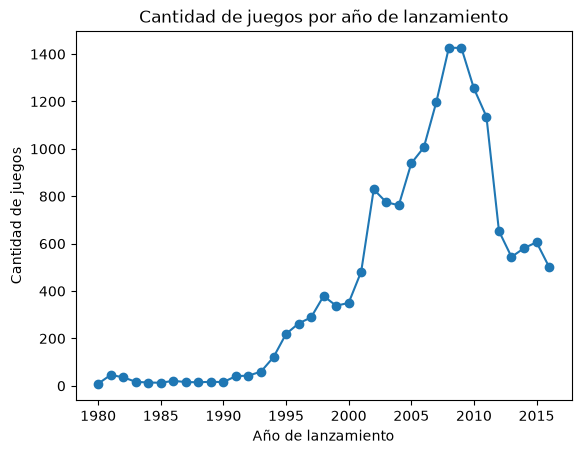

In [16]:
# Grafico la cantidad de juegos por año de lanzamiento

games_per_year.plot(x='year_of_release',
                    y='count',
                    title='Cantidad de juegos por año de lanzamiento',
                    style='o-',
                    xlabel='Año de lanzamiento',
                    ylabel='Cantidad de juegos',
                    legend=False
                    )
plt.show()

- 1980-1993 la cantidad de videojuegos fue muy baja (<=60)
- 1994-2008 hay un aumento en la cantidad de videojuegos lanzados.
- 2008-2009 se alcanza el pico de videojuegos lanzados (1427).
- 2011-2012 la cantidad de videojuegos se reduce a la mitad en un solo año, posiblemente por la masificación de tecnologías como el smartphone.
- 2016 según la descripción del dataset los datos están incompletos por lo que no es posible saber si el aumento de videojuegos continuó como en los tres años anteriores o se fue a la baja.

No todos los períodos son igual de útiles. Los años anteriores a 1994 tienen muy pocos datos. Los años del pico (2008–2009) muestran un mercado muy distinto del actual, con más del doble de lanzamientos. Para planificar la campaña de 2017, lo más relevante son los años posteriores a la caída de 2012, porque reflejan cómo es el mercado ahora. El período exacto lo definiré después de analizar el ciclo de vida de las plataformas.

In [17]:
# Ventas totales de videojuegos según la plataforma

sales_per_platform = df.groupby('platform')['total_sales'].sum().sort_values(ascending=False).reset_index()


display(sales_per_platform)

,platform,total_sales
0,PS2,1233.56
1,X360,961.24
2,PS3,931.34
3,Wii,891.18
4,DS,802.78
5,PS,727.58
6,PS4,314.14
7,GBA,312.88
8,PSP,289.53
9,3DS,257.81


De acuerdo a la tabla anterior, me quedo con estas 6 plataformas que son las que más ventas generaron.

1. PS2
2. X360
3. PS3
4. Wii
5. DS
6. PS

Para mí son las más significativas ya que la PS4 tiene 314.14 millones en ventas respecto a PS con 727.58
Después de PS4 las ventas de las plataformas son mucho más cercanas.

In [18]:
# Distribución por año de las plataformas elegidas

top_platforms = sales_per_platform['platform'].head(6)

# Filtro el dataset para quedarme solo con esas plataformas

top_platforms_df = df[df['platform'].isin(top_platforms)]

# Agrupo por plataforma y año, y sumo las ventas
platform_distribution = (
    top_platforms_df.
    groupby(['platform', 'year_of_release'])['total_sales']
    .sum()
    .reset_index()
    )

display(platform_distribution)

,platform,year_of_release,total_sales
0,DS,2004,17.27
1,DS,2005,130.14
2,DS,2006,119.81
3,DS,2007,146.96
4,DS,2008,145.31
...,...,...,...
61,X360,2012,99.74
62,X360,2013,88.58
63,X360,2014,34.74
64,X360,2015,11.96


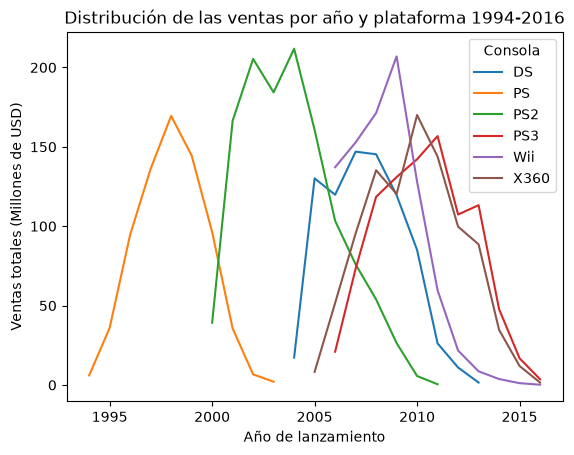

In [19]:
# Grafico la distribución de las ventas por año y plataforma 1994-2016

sns.lineplot(data= platform_distribution,
             x= 'year_of_release',
             y='total_sales',
             hue= 'platform'
)
plt.title('Distribución de las ventas por año y plataforma 1994-2016')
plt.xlabel('Año de lanzamiento')
plt.ylabel('Ventas totales (Millones de USD)')
plt.legend(title='Consola')
plt.show()

* Una plataforma dura entre 10 y 12 años desde que aparece hasta que deja de vender.
* Las plataformas alcanzan su pico de ventas entre 3 y 5 años después de su lanzamiento. Después de eso las ventas empiezan a bajar.
* Entre una generación y la siguiente pasan unos 6 años. Por ejemplo, PS salió en 1994, PS2 en 2000 y PS3 en 2006.
* Cuando sale la nueva generación, las ventas de la anterior caen rápidamente. PS pasó de 96.37 millones en 2000 a 6.67 millones en 2002, justo después de la salida de PS2.
* Ninguna de estas 6 plataformas sigue vendiendo bien en 2016. PS, PS2 y DS ya desaparecieron, y X360 (1.52), PS3 (3.60) y Wii (0.18) están a punto de desaparecer.

Para mí, esto significa que las plataformas que más vendieron en la historia no son las que conviene elegir para 2017. Como una plataforma tarda entre 3 y 5 años en llegar a su pico, lo más relevante es analizar las plataformas de la generación actual, que aparecieron a partir de 2013 (PS4 y XOne). Por eso voy a tomar los datos de 2013 a 2016 para el resto del análisis.

<div class="alert alert-block alert-success">
<b>Comentario de la revisora. (Iteración 1)</b> <a class="tocSkip"></a><br>
<b>Éxito ✅</b><br>
Muy buen análisis de la evolución histórica y del ciclo de vida de las plataformas. Justificas de forma clara por qué las plataformas con mayores ventas históricas no necesariamente son las más útiles para planificar 2017 y utilizas ese razonamiento para definir un período reciente.
</div>


In [20]:
# Creo un nuevo dataframe con el año de lanzamiento superior a 2012

df_relevant = df[df['year_of_release'] > 2012]

df_relevant.info()

df_relevant['year_of_release'].value_counts().sort_index(ascending=True)

<class 'pandas.DataFrame'>
Index: 2233 entries, 16 to 16714
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             2233 non-null   str    
 1   platform         2233 non-null   str    
 2   year_of_release  2233 non-null   Int64  
 3   genre            2233 non-null   str    
 4   na_sales         2233 non-null   float64
 5   eu_sales         2233 non-null   float64
 6   jp_sales         2233 non-null   float64
 7   other_sales      2233 non-null   float64
 8   critic_score     991 non-null    float64
 9   user_score       1192 non-null   float64
 10  rating           2233 non-null   str    
 11  total_sales      2233 non-null   float64
dtypes: Int64(1), float64(7), str(4)
memory usage: 229.0 KB


year_of_release
2013    544
2014    581
2015    606
2016    502
Name: count, dtype: Int64

In [21]:
# Ventas totales de videojuegos según la plataforma

sales_per_platform_relevant = df_relevant.groupby('platform')['total_sales'].sum().sort_values(ascending=False).reset_index()


display(sales_per_platform_relevant)

,platform,total_sales
0,PS4,314.14
1,PS3,181.43
2,XOne,159.32
3,3DS,143.25
4,X360,136.80
5,WiiU,64.63
6,PC,39.43
7,PSV,32.99
8,Wii,13.66
9,PSP,3.50


De acuerdo a la tabla anterior, me quedo con estas 5 plataformas que son las que más ventas generaron entre 2013 y 2016.

1. PS4
2. PS3
3. XOne
4. 3DS
5. X360

Para mí son las más significativas ya que la X360 tiene 136.80 millones en ventas y la WiiU, que es la siguiente, solo tiene 64.63 millones, menos de la mitad. Después de WiiU las ventas de las plataformas son mucho más bajas.

También noté que la PS4, que en el ranking histórico estaba en el puesto 7, en este período es la plataforma líder con 314.14 millones en ventas, casi el doble que la PS3.

In [22]:
# Distribución por año de las plataformas elegidas

relevant_platforms = sales_per_platform_relevant['platform'].head(5)

# Filtro el dataset para quedarme solo con esas plataformas

relevant_platforms_df = df_relevant[df_relevant['platform'].isin(relevant_platforms)]

# Agrupo por plataforma y año, y sumo las ventas
platform_distribution_relevant = (
    relevant_platforms_df.
    groupby(['platform', 'year_of_release'])['total_sales']
    .sum()
    .reset_index()
    )

display(platform_distribution_relevant)

,platform,year_of_release,total_sales
0,3DS,2013,56.57
1,3DS,2014,43.76
2,3DS,2015,27.78
3,3DS,2016,15.14
4,PS3,2013,113.25
5,PS3,2014,47.76
6,PS3,2015,16.82
7,PS3,2016,3.60
8,PS4,2013,25.99
9,PS4,2014,100.00


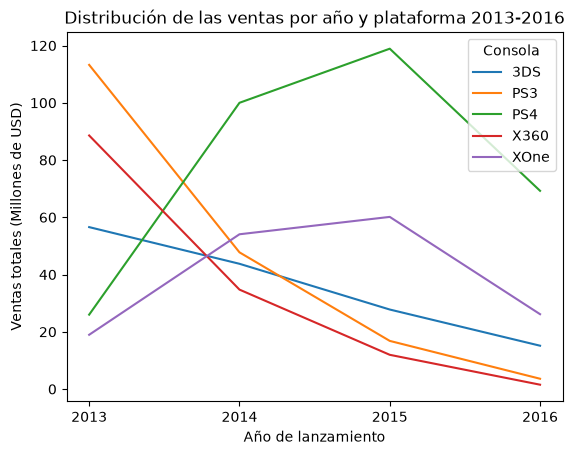

In [23]:
# Grafico la distribución de las ventas por año y plataforma

sns.lineplot(data= platform_distribution_relevant,
             x= 'year_of_release',
             y='total_sales',
             hue= 'platform'
)
plt.title('Distribución de las ventas por año y plataforma 2013-2016')
plt.xlabel('Año de lanzamiento')
plt.ylabel('Ventas totales (Millones de USD)')
plt.legend(title='Consola')
plt.xticks([2013, 2014, 2015, 2016])
plt.show()

* Plataformas con aumento de ventas: PS4 y XOne. Las dos salieron en 2013 y sus ventas aumentaron hasta 2015. PS4 pasó de 25.99 a 118.90 millones y XOne de 18.96 a 60.14 millones.
* Plataformas que bajan sus ventas: PS3, X360 y 3DS. Sus ventas bajan todos los años. PS3 pasó de 113.25 a 3.60 millones y X360 de 88.58 a 1.52 millones. Esto coincide con lo que vi en el análisis anterior: cuando sale la nueva generación, las ventas de la anterior caen rápidamente.
* El caso de 2016: todas las plataformas bajan, pero no de la misma manera. PS3 y X360 ya venían cayendo y están a punto de desaparecer. En cambio, PS4  y XOne venían creciendo y solo tienen 3 años de vida, cuando normalmente el pico llega entre 3 y 5 años después del lanzamiento. Como es posible que los datos de 2016 estén incompletos, para mí esta caída no significa necesariamente que PS4 y XOne hayan empezado a desaparecer del mercado.

### Plataformas potencialmente rentables
Para la campaña de 2017, las plataformas potencialmente rentables son:

* PS4: es la líder en ventas del período y en 2017 tendrá 4 años, es decir, estará todavía en su mejor etapa.
* XOne: es la segunda plataforma de la nueva generación. Vende menos que PS4, pero también está en crecimiento y en la misma etapa de su ciclo de vida.
* 3DS: sus ventas bajan cada año, pero sigue siendo la 4ª plataforma con más ventas del período por lo que esta decisión puede cambiar más adelante.

Descarto PS3 y X360 porque están al final de su ciclo de vida y en 2016 casi no tuvieron ventas. Para mí no tiene sentido invertir en publicidad para plataformas que están desapareciendo.

<div class="alert alert-block alert-success">
<b>Comentario de la revisora. (Iteración 1)</b> <a class="tocSkip"></a><br>
<b>Éxito ✅</b><br>
El análisis de plataformas recientes está bien desarrollado. Filtras 2013–2016, comparas la evolución anual, distingues plataformas en crecimiento y en declive y propones PS4 y XOne como candidatas para 2017 con una justificación basada en su etapa del ciclo de vida.
</div>


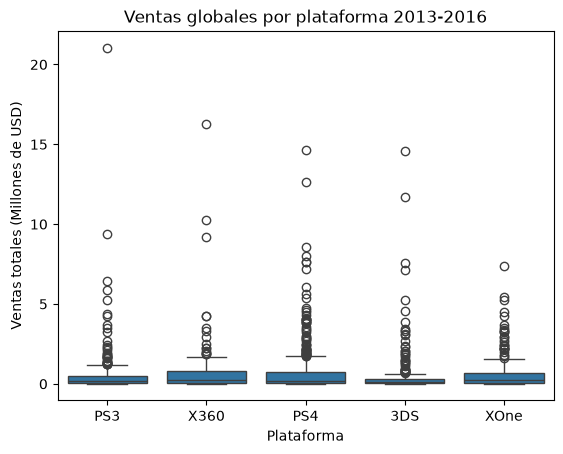

In [24]:
# Diagrama de caja de las ventas globales por plataforma (2013-2016)

sns.boxplot(data=relevant_platforms_df,
            x='platform',
            y='total_sales')
plt.title('Ventas globales por plataforma 2013-2016')
plt.xlabel('Plataforma')
plt.ylabel('Ventas totales (Millones de USD)')
plt.show()

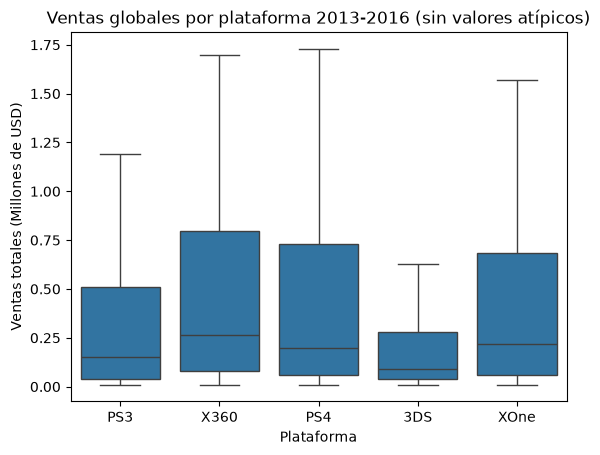

In [25]:
# Mismo diagrama sin los valores atípicos, para ver las cajas con detalle

sns.boxplot(data=relevant_platforms_df,
            x='platform',
            y='total_sales',
            showfliers=False)
plt.title('Ventas globales por plataforma 2013-2016 (sin valores atípicos)')
plt.xlabel('Plataforma')
plt.ylabel('Ventas totales (Millones de USD)')
plt.show()

In [26]:
# Estadísticas de las ventas por plataforma

sales_stats = (
    relevant_platforms_df
    .groupby('platform')['total_sales']
    .agg(['count', 'mean', 'median', 'std', 'var'])
    .sort_values(by='median', ascending=False)
    .round(2)
)

display(sales_stats)

,count,mean,median,std,var
platform,,,,,
X360,186,0.74,0.26,1.66,2.77
XOne,247,0.65,0.22,1.04,1.07
PS4,392,0.80,0.20,1.61,2.59
PS3,345,0.53,0.15,1.45,2.11
3DS,303,0.47,0.09,1.38,1.91


* Las diferencias en las ventas entre plataformas no son tan grandes como parecía. La mediana va de 0.09 millones en 3DS a 0.26 millones en X360.
* En todas las plataformas la media es mayor que la mediana. Por ejemplo, PS4 tiene una media de 0.80 millones y una mediana de 0.20 millones. Esto significa que la distribución está sesgada a la derecha: la mayoría de los juegos vende muy poco y unos pocos éxitos venden muchísimo y arrastran la media hacia arriba.
* Por eso hay tantos valores atípicos en el diagrama de caja. En PS4, por ejemplo, el 13.8% de los juegos quedan por encima del bigote superior. Se entiende que son los juegos más vendidos de cada plataforma.
* PS4 es la plataforma que más vendió en total (314.14 millones), pero no es la que tiene la mediana más alta. Para mí, esto quiere decir que PS4 vende más porque tiene más catálogo de videojuegos más grande y no porque cada juego venda más.

Para mí, la conclusión general es que el éxito de un juego depende más de la popularidad del videojuego en sí que de la plataforma. Aun así, publicar en una plataforma con mucho catálogo y muchas ventas totales, como PS4, da más oportunidades de llegar a un éxito.

<div class="alert alert-block alert-success">
<b>Comentario de la revisora. (Iteración 1)</b> <a class="tocSkip"></a><br>
<b>Éxito ✅</b><br>
Los boxplots y las estadísticas descriptivas permiten comparar correctamente las distribuciones de ventas por plataforma. Interpretas bien la asimetría y la diferencia entre media y mediana, reconociendo que unos pocos éxitos elevan considerablemente el promedio.
</div>


In [27]:
# Selecciono PS4, que es la plataforma más popular del período

ps4_games = df_relevant[df_relevant['platform'] == 'PS4']

print(f"Juegos de PS4 en el período: {len(ps4_games)}")
print(f"Con reseñas de críticos: {ps4_games['critic_score'].notna().sum()}")
print(f"Con reseñas de usuarios: {ps4_games['user_score'].notna().sum()}")

Juegos de PS4 en el período: 392
Con reseñas de críticos: 252
Con reseñas de usuarios: 257


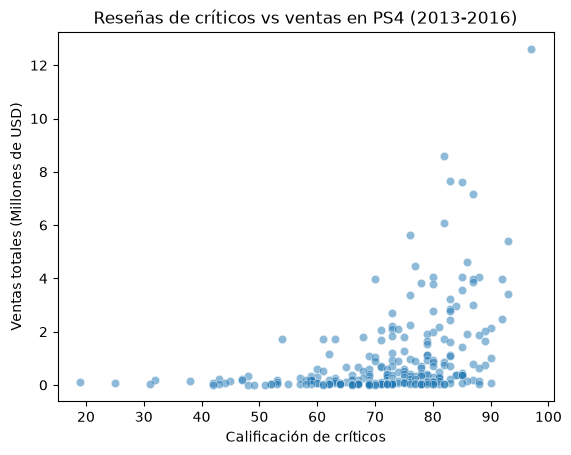

In [28]:
# Diagrama de dispersión entre las reseñas de críticos y las ventas

sns.scatterplot(data=ps4_games,
                x='critic_score',
                y='total_sales',
                alpha=0.5)
plt.title('Reseñas de críticos vs ventas en PS4 (2013-2016)')
plt.xlabel('Calificación de críticos')
plt.ylabel('Ventas totales (Millones de USD)')
plt.show()

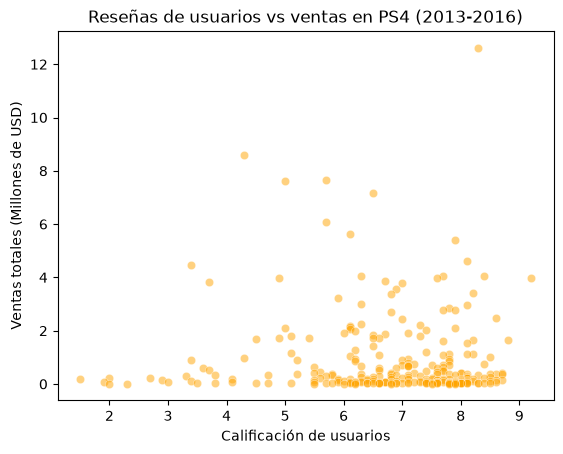

In [29]:
# Diagrama de dispersión entre las reseñas de usuarios y las ventas

sns.scatterplot(data=ps4_games,
                x='user_score',
                y='total_sales',
                alpha=0.5,
                color='orange')
plt.title('Reseñas de usuarios vs ventas en PS4 (2013-2016)')
plt.xlabel('Calificación de usuarios')
plt.ylabel('Ventas totales (Millones de USD)')
plt.show()

In [30]:
# Calculo la correlación entre las reseñas y las ventas en PS4

critic_corr = ps4_games['critic_score'].corr(ps4_games['total_sales'])
user_corr = ps4_games['user_score'].corr(ps4_games['total_sales'])

print(f"Correlación entre las reseñas de críticos y las ventas: {critic_corr:.2f}")
print(f"Correlación entre las reseñas de usuarios y las ventas: {user_corr:.2f}")

Correlación entre las reseñas de críticos y las ventas: 0.41
Correlación entre las reseñas de usuarios y las ventas: -0.03


Elegí PS4 porque es la plataforma con más ventas del período. De sus 392 juegos, 252 tienen reseñas de críticos y 257 de usuarios, así que hay datos suficientes para el análisis.

* Reseñas de críticos: la correlación con las ventas es de 0.41, una correlación positiva moderada. En el diagrama de dispersión se ve que casi no hay juegos con nota alta de la crítica y ventas muy bajas, pero sí muchos juegos con nota alta que venden poco. Es decir, una buena nota de la crítica no garantiza ventas altas, pero una mala nota casi siempre viene acompañada de ventas bajas.
* Reseñas de usuarios: la correlación es de −0.03, prácticamente cero. En el diagrama los puntos están repartidos sin ninguna forma clara. Para mí, esto significa que la calificación de los usuarios no sirve para predecir las ventas de un juego en PS4.
* Una posible explicación de esta diferencia es que las reseñas de los críticos se publican antes o justo cuando sale el juego, mientras que las de los usuarios llegan después de la compra. Aun así, la correlación solo muestra una asociación: estos datos no permiten demostrar que las reseñas causen cambios en las ventas.

De los 392 juegos publicados en PS4, solo 252 (64%) de ellos tienen reseñas de críticos. Los juegos pequeños que nadie reseñó quedan fuera del cálculo.

<div class="alert alert-block alert-warning">
<b>Comentario de la revisora. (Iteración 1)</b> <a class="tocSkip"></a><br>
<b>Atención ⚠️</b><br>
Muy buen cálculo de las correlaciones para PS4: aproximadamente 0.41 entre <code>critic_score</code> y ventas y -0.03 entre <code>user_score</code> y ventas. Como mejora, mantén la interpretación en términos de <b>asociación</b>. El hecho de que las reseñas de críticos aparezcan antes que las de usuarios es una explicación posible, pero estos datos por sí solos no permiten demostrar que las reseñas causen cambios en las ventas.
</div>


In [31]:
# Busco los juegos que salieron en más de una de las plataformas elegidas

games_by_platform_count = relevant_platforms_df.groupby('name')['platform'].nunique()
multiplatform_games = games_by_platform_count[games_by_platform_count > 1].index

multiplatform_df = relevant_platforms_df[relevant_platforms_df['name'].isin(multiplatform_games)]

print(f"Juegos multiplataforma: {len(multiplatform_games)} de {relevant_platforms_df['name'].nunique()}")

Juegos multiplataforma: 365 de 879


In [32]:
# Creo una tabla con las ventas de cada juego en cada plataforma

sales_by_game = multiplatform_df.pivot_table(index='name',
                                             columns='platform',
                                             values='total_sales')

# Selecciono los 8 juegos multiplataforma con más ventas totales

top_multiplatform = (
    multiplatform_df
    .groupby('name')['total_sales']
    .sum()
    .sort_values(ascending=False)
    .head(8)
    .index
)

display(sales_by_game.loc[top_multiplatform])

platform,3DS,PS3,PS4,X360,XOne
name,,,,,
Grand Theft Auto V,NaN,21.05,12.62,16.27,5.47
Call of Duty: Ghosts,NaN,9.36,3.83,10.24,2.92
Call of Duty: Black Ops 3,NaN,1.69,14.63,1.70,7.39
Call of Duty: Advanced Warfare,NaN,4.36,7.66,4.28,5.26
Minecraft,NaN,5.27,4.32,9.18,2.76
FIFA 16,NaN,2.70,8.58,1.57,3.25
FIFA 15,0.46,4.28,6.08,2.92,2.18
FIFA 14,0.23,6.46,3.01,4.22,1.16


In [33]:
# Comparo las ventas de los juegos multiplataforma en cada plataforma

multiplatform_stats = (
    multiplatform_df
    .groupby('platform')['total_sales']
    .agg(['count', 'mean', 'median', 'sum'])
    .sort_values(by='mean', ascending=False)
    .round(2)
)

display(multiplatform_stats)

,count,mean,median,sum
platform,,,,
PS4,283,0.97,0.34,275.92
X360,180,0.75,0.27,134.48
PS3,237,0.66,0.24,156.68
XOne,222,0.60,0.22,134.29
3DS,37,0.20,0.13,7.47


In [34]:
# Comparo directamente PS4 y XOne en los juegos que salieron en las dos plataformas

ps4_vs_xone = sales_by_game.dropna(subset=['PS4', 'XOne'])
ps4_over_xone = ps4_vs_xone['PS4'].sum() / ps4_vs_xone['XOne'].sum()

print(f"Juegos en PS4 y XOne: {len(ps4_vs_xone)}")
print(f"Venta promedio en PS4: {ps4_vs_xone['PS4'].mean():.2f} millones de dólares")
print(f"Venta promedio en XOne: {ps4_vs_xone['XOne'].mean():.2f} millones de dólares")
print(f"PS4 vende {ps4_over_xone:.2f} veces lo que vende XOne")

Juegos en PS4 y XOne: 217
Venta promedio en PS4: 1.18 millones de dólares
Venta promedio en XOne: 0.60 millones de dólares
PS4 vende 1.98 veces lo que vende XOne


De los 879 videojuegos, 365 salieron en más de una de las 5 plataformas elegidas. Estos juegos permiten comparar plataformas sin que influya la calidad del juego, porque se trata del mismo videojuego.

* El mismo videojuego vende distinto según la plataforma. Grand Theft Auto V vendió 21.05 millones de dólares en PS3, 16.27 en X360, 12.62 en PS4 y solo 5.47 en XOne. La diferencia entre la mejor y la peor plataforma es de casi 4 veces.
* Lo que manda es el año del videojuego, no la plataforma en sí. Grand Theft Auto V salió en 2013, cuando PS3 y X360 tenían millones de consolas vendidas y PS4 y XOne acababan de aparecer. En cambio, Call of Duty: Black Ops 3, que salió en 2015, vendió 14.63 millones en PS4 y solo 1.69 en PS3. El mercado se mueve de una generación a la otra.
* PS4 es la mejor plataforma para publicar. En los videojuegos multiplataforma tiene la venta promedio más alta (0.97 millones) y la mediana más alta (0.34 millones).
* Comparando PS4 y XOne directamente, hay 217 videojuegos que salieron en las dos. En PS4 venden en promedio 1.18 millones de dólares y en XOne 0.60 millones de dólares. Es decir, PS4 vende casi el doble que XOne para exactamente los mismos videojuegos.
* Solo 37/303 de los juegos publicados en 3DS son multiplataforma y venden muy poco (0.20 millones de promedio). Casi todo su catálogo es exclusivo, así que no compite por los mismos juegos que las demás plataformas.

Según lo anterior, se confirma mi decisión sobre las plataformas rentables: una campaña para 2017 debería priorizar PS4, con XOne como segunda opción. Descarto 3DS para Norteamérica y Europa, ya que casi no comparte juegos con las demás plataformas y sus títulos multiplataforma venden muy poco. Su potencial está en su catálogo exclusivo, que analizaré en el perfil de usuario por región.

<div class="alert alert-block alert-success">
<b>Comentario de la revisora. (Iteración 1)</b> <a class="tocSkip"></a><br>
<b>Éxito ✅</b><br>
Excelente comparación de juegos multiplataforma. No te limitas a un título aislado: construyes una tabla por juego y plataforma, comparas PS4 frente a XOne y reconoces cómo el momento de lanzamiento y el tamaño de la base instalada pueden modificar el desempeño del mismo videojuego.
</div>


In [35]:
# Cantidad de juegos y ventas por género en el período

genre_stats = (
    df_relevant
    .groupby('genre')['total_sales']
    .agg(['count', 'sum', 'mean', 'median'])
    .sort_values(by='sum', ascending=False)
    .round(2)
)

display(genre_stats)

,count,sum,mean,median
genre,,,,
Action,766,321.87,0.42,0.11
Shooter,187,232.98,1.25,0.45
Sports,214,150.65,0.70,0.24
Role-Playing,292,145.89,0.50,0.12
Misc,155,62.82,0.41,0.10
Platform,74,42.63,0.58,0.22
Racing,85,39.89,0.47,0.12
Fighting,80,35.31,0.44,0.12
Adventure,245,23.64,0.10,0.03


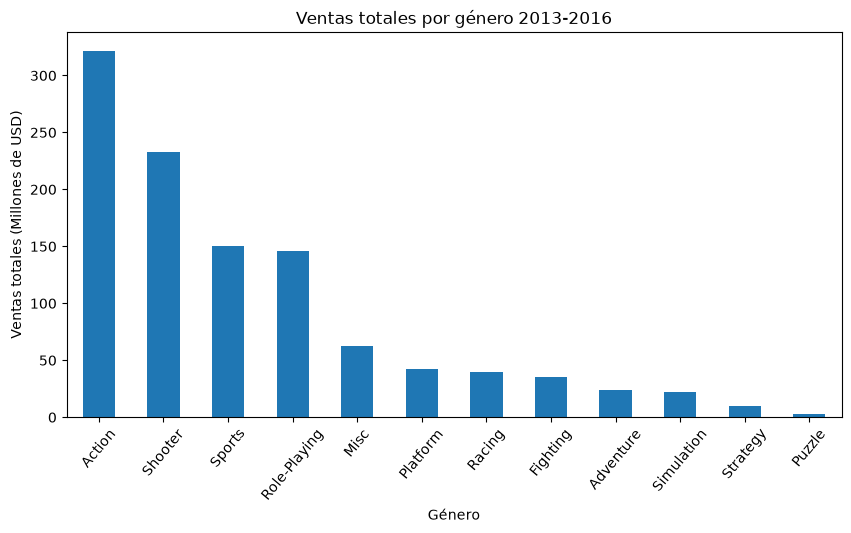

In [36]:
# Grafico las ventas totales por género

genre_stats['sum'].plot(kind='bar',
                        title='Ventas totales por género 2013-2016',
                        xlabel='Género',
                        ylabel='Ventas totales (Millones de USD)',
                        rot=50,
                        figsize=(10, 5)
                        )
plt.show()

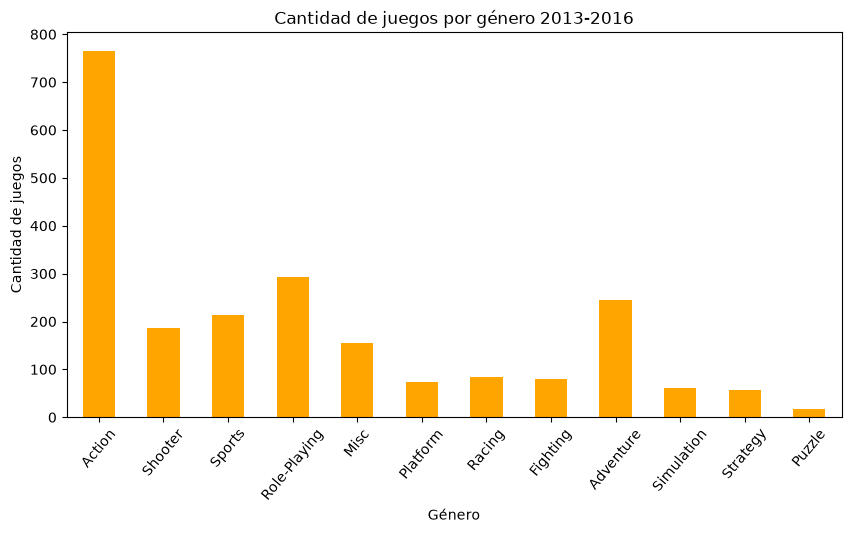

In [37]:
# Grafico la cantidad de juegos lanzados por género

genre_stats['count'].plot(kind='bar',
                          title='Cantidad de juegos por género 2013-2016',
                          xlabel='Género',
                          ylabel='Cantidad de juegos',
                          rot=50,
                          figsize=(10, 5),
                          color='orange'
                          )
plt.show()

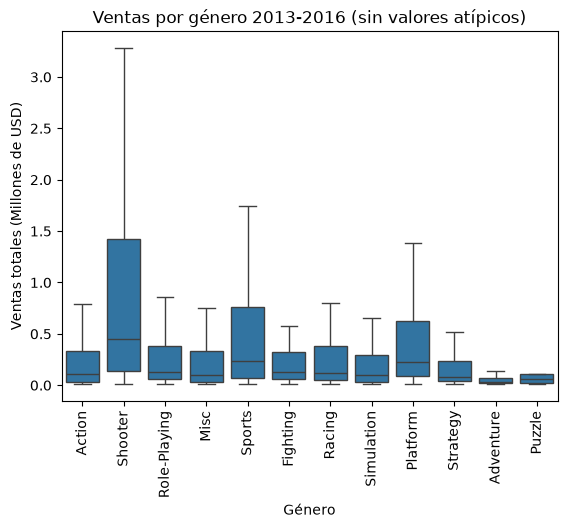

In [38]:
# Diagrama de caja de las ventas por género

sns.boxplot(data=df_relevant,
            x='genre',
            y='total_sales',
            showfliers=False)
plt.title('Ventas por género 2013-2016 (sin valores atípicos)')
plt.xlabel('Género')
plt.ylabel('Ventas totales (Millones de USD)')
plt.xticks(rotation=90)
plt.show()

* El género Action es el que tiene más ventas totales (321.87 millones), pero no el más rentable. Es el género que más juegos tiene: 766 de los 2233, es decir, casi un tercio del catálogo. Sus ventas altas se explican por la cantidad de juegos, no por lo que vende cada uno ya que su mediana es de solo 0.11 millones de dólares.
* El género Shooter es el más rentable. Con solo 187 juegos vendió 232.98 millones, casi lo mismo que el género Action con cuatro veces menos títulos. Su mediana es de 0.45 millones de dólares, cuatro veces la del género Action.
* Después de Shooter vienen Sports (mediana 0.24) y Platform (mediana 0.22). Son géneros con pocos juegos pero con un público fiel.
* Adventure es el peor caso. Tiene 245 juegos, más que Shooter, pero solo vendió 23.64 millones de dólares en total y su mediana es de 0.03 millones. Junto con Strategy y Puzzle son los géneros con ventas más bajas.
* Generalizando: los géneros con ventas altas son los de acción y competencia, pensados para consolas y para un público amplio (Shooter, Sports, Platform). Los géneros con ventas bajas son los más pausados (Adventure, Strategy, Puzzle, Simulation), donde además hay muchos juegos pequeños que venden muy poco.
  
Los tres primeros géneros suman más de 700 millones dólares de los 1090 del período. Para mí, una campaña para 2017 debería concentrarse en juegos de los géneros Action, Shooter y Sports, aunque en el género Action hay que elegir bien el título porque la mayoría vende muy poco.

<div class="alert alert-block alert-success">
<b>Comentario de la revisora. (Iteración 1)</b> <a class="tocSkip"></a><br>
<b>Éxito ✅</b><br>
Muy buen análisis por género. Diferencias correctamente ventas acumuladas, cantidad de títulos y ventas típicas por juego; esto te permite evitar la conclusión simplista de que el género con mayor volumen total es necesariamente el más rentable.
</div>


## Perfiles de Usuarios

In [39]:
# Defino las regiones que voy a analizar

regions = {'na_sales': 'Norteamérica',
           'eu_sales': 'Europa',
           'jp_sales': 'Japón'}

display(regions)

{'na_sales': 'Norteamérica', 'eu_sales': 'Europa', 'jp_sales': 'Japón'}

In [40]:
# Las 5 plataformas principales de cada región, con su cuota de mercado

for region, region_name in regions.items():
    top_platforms_region = (
        df_relevant
        .groupby('platform')[region]
        .sum()
        .sort_values(ascending=False)
        .head(5)
    )
    market_share = (top_platforms_region / df_relevant[region].sum() * 100).round(1)

    print(f"--- {region_name} ---")
    print(f"Ventas totales de la región: {df_relevant[region].sum():.2f} millones de USD")
    print(market_share)
    print()

--- Norteamérica ---
Ventas totales de la región: 437.71 millones de USD
platform
PS4     24.8
XOne    21.3
X360    18.7
PS3     14.5
3DS      8.7
Name: na_sales, dtype: float64

--- Europa ---
Ventas totales de la región: 392.23 millones de USD
platform
PS4     36.0
PS3     17.3
XOne    13.2
X360    10.8
3DS      7.9
Name: eu_sales, dtype: float64

--- Japón ---
Ventas totales de la región: 140.78 millones de USD
platform
3DS     48.2
PS3     16.6
PSV     13.2
PS4     11.3
WiiU     7.7
Name: jp_sales, dtype: float64



In [41]:
# Los 5 géneros principales de cada región

for region, region_name in regions.items():
    top_genres_region = (
        df_relevant
        .groupby('genre')[region]
        .sum()
        .sort_values(ascending=False)
        .head(5)
    )
    genre_share = (top_genres_region / df_relevant[region].sum() * 100).round(1)

    print(f"--- {region_name} ---")
    print(genre_share)
    print()

--- Norteamérica ---
genre
Action          28.8
Shooter         25.1
Sports          14.9
Role-Playing    10.6
Misc             6.3
Name: na_sales, dtype: float64

--- Europa ---
genre
Action          30.1
Shooter         22.4
Sports          15.4
Role-Playing     9.4
Racing           5.1
Name: eu_sales, dtype: float64

--- Japón ---
genre
Role-Playing    36.3
Action          28.8
Misc             6.5
Fighting         5.4
Shooter          4.7
Name: jp_sales, dtype: float64



In [42]:
# Ventas por clasificación ESRB en cada región

rating_by_region = (
    df_relevant
    .groupby('rating')[['na_sales', 'eu_sales', 'jp_sales']]
    .sum()
    .sort_values(by='na_sales', ascending=False)
    .round(2)
)

# Calculo el porcentaje que representa cada clasificación en su región

rating_share = (rating_by_region / rating_by_region.sum() * 100).round(1)

print("--- Ventas en millones de USD por clasificación ESRB en cada región ---")
display(rating_by_region)

print("--- Porcentaje que representa cada clasificación en su región ---")
display(rating_share)

--- Ventas en millones de USD por clasificación ESRB en cada región ---


,na_sales,eu_sales,jp_sales
rating,,,
M,165.21,145.32,14.11
unknown,89.42,78.91,85.05
E,79.05,83.36,15.14
E10+,54.24,42.69,5.89
T,49.79,41.95,20.59


--- Porcentaje que representa cada clasificación en su región ---


,na_sales,eu_sales,jp_sales
rating,,,
M,37.7,37.0,10.0
unknown,20.4,20.1,60.4
E,18.1,21.3,10.8
E10+,12.4,10.9,4.2
T,11.4,10.7,14.6


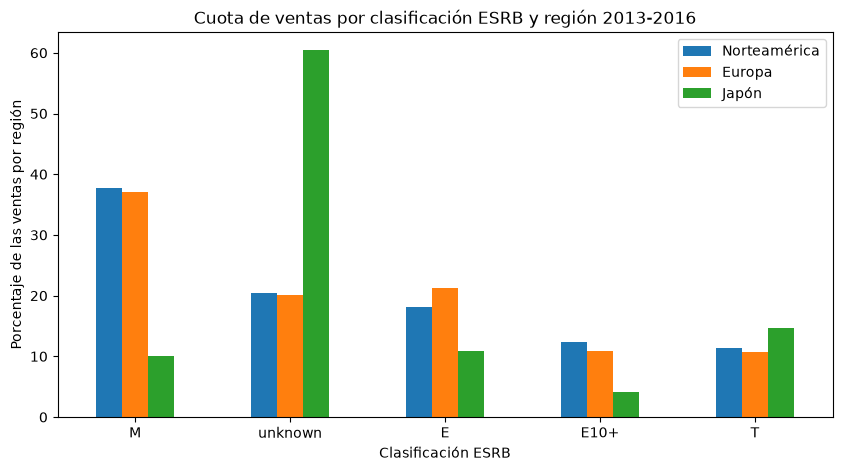

In [43]:
# Grafico las ventas por clasificación ESRB en cada región

rating_share.plot(kind='bar',
                  title='Cuota de ventas por clasificación ESRB y región 2013-2016',
                  xlabel='Clasificación ESRB',
                  ylabel='Porcentaje de las ventas por región',
                  rot=0,
                  figsize=(10, 5)
                  )
plt.legend(['Norteamérica', 'Europa', 'Japón'])
plt.show()

**Plataformas**
* Norteamérica y Europa se parecen mucho. En las dos regiones PS4 es la plataforma líder, aunque en Europa tiene ventas más grandes.
* X360 y XOne solo son fuertes en Norteamérica y en Japón ni siquiera aparecen entre las 5 primeras. Es lógico porque Microsoft es una empresa estadounidense.
* Japón es un mercado completamente distinto. La 3DS sola tiene el 48.2% de las ventas, casi la mitad. Además, la PSV, que en las otras regiones no aparece, aquí es la tercera con el 13.2%. Las dos son consolas portátiles, así que en Japón se juega sobre todo en portátil.
* La PS4, que es la líder en los mercados de Norteamérica y Europa. En Japón solo tiene el 11.3%. Esto confirma lo que dejé pendiente en el análisis de plataformas: la 3DS es una plataforma a tener en cuenta, pero solo si en la campaña incluimos a Japón.

**Géneros**
* Norteamérica y Europa comparten los tres primeros géneros: Action, Shooter y Sports, en el mismo orden. Entre los tres suman cerca del 68% de las ventas en las dos regiones. La única diferencia es el quinto puesto: Misc en Norteamérica y Racing en Europa.
* Japón vuelve a ser la excepción. El género más vendido es Role-Playing con el 36.3%, muy por delante de Action. Y el Shooter, que en Norteamérica y Europa es el segundo con más del 22%, en Japón es el quinto con solo el 4.7%.
* Para mí, la explicación está en el tipo de consola: los juegos de disparos se juegan sobre todo en consolas de sobremesa, y los juegos de rol japoneses tienen más presencia en las plataformas portátiles como 3DS.

**Clasificación ESRB**
* En Norteamérica y Europa la clasificación sí está relacionada con las ventas. Los juegos con clasificación M (para adultos) concentran el 37% de las ventas en las dos regiones, aunque solo son 369 juegos de 2233.
* Los videojuegos de Shooter y Action son los que reciben la clasificación M, por lo que se entiende que, la clasificación no es la causa de las ventas, sino una consecuencia del tipo de juego.
* Los juegos con clasificación `unknown` representan el 20.4% de las ventas en Norteamérica y el 20.1% en Europa. Son juegos sin clasificación registrada en el dataset, por lo que no se puede saber qué clasificación tenían.
* En Japón, el 60.4% de las ventas corresponde a juegos con clasificación `unknown`. Una posible explicación es que la ESRB clasifica juegos para Norteamérica y muchos juegos que solo se venden en Japón no pasan por ella. Por eso la clasificación ESRB no permite sacar conclusiones sobre el mercado japonés.
* Los juegos con clasificación M solo representan el 10% de las ventas japonesas, lo que encaja con que allí el género Shooter apenas vende.

<div class="alert alert-block alert-danger">
<b>Comentario de la revisora. (Iteración 1)</b> <a class="tocSkip"></a><br>
<b>A resolver 🔴</b><br>
El perfil regional por plataformas y géneros está bien construido, pero necesitamos corregir el tratamiento de <code>rating</code> antes de validar la parte ESRB.

Actualmente los valores ausentes se reemplazan por <code>'RP'</code>. El problema es que <code>RP</code> no significa “sin clasificación conocida”; es una categoría ESRB real (“Rating Pending”). Al combinar los nulos con esa categoría, el análisis mezcla juegos realmente etiquetados como RP con juegos cuyo rating simplemente falta.

Esto afecta directamente porcentajes como el 60.4% atribuido a RP en Japón y la conclusión de que ese porcentaje representa juegos “sin clasificar”. Usa una categoría distinta para los valores ausentes, vuelve a calcular la distribución ESRB por región y revisa las conclusiones que dependan de esos porcentajes.
</div>


## Prueba de hipótesis

In [44]:
# Preparo los datos para las pruebas de hipótesis
# Uso solo el período relevante (2013-2016) y quito los valores ausentes

xone_scores = df_relevant[df_relevant['platform'] == 'XOne']['user_score'].dropna()
pc_scores = df_relevant[df_relevant['platform'] == 'PC']['user_score'].dropna()

print(f"XOne: {len(xone_scores)} juegos con reseña, media {xone_scores.mean():.2f}, varianza {xone_scores.var():.2f}")
print(f"PC: {len(pc_scores)} juegos con reseña, media {pc_scores.mean():.2f}, varianza {pc_scores.var():.2f}")

XOne: 182 juegos con reseña, media 6.52, varianza 1.91
PC: 155 juegos con reseña, media 6.27, varianza 3.04


In [45]:
# Hipótesis 1: las calificaciones promedio de los usuarios para XOne y PC son las mismas

alpha = 0.05

results_1 = st.ttest_ind(xone_scores, pc_scores, equal_var=False)

print(f"Valor p: {results_1.pvalue}")

if results_1.pvalue < alpha:
    print("Rechazamos la hipótesis nula")
else:
    print("No podemos rechazar la hipótesis nula")

Valor p: 0.1475959401343046
No podemos rechazar la hipótesis nula


In [46]:
# Preparo los datos de la segunda hipótesis

action_scores = df_relevant[df_relevant['genre'] == 'Action']['user_score'].dropna()
sports_scores = df_relevant[df_relevant['genre'] == 'Sports']['user_score'].dropna()

print(f"Action: {len(action_scores)} juegos con reseña, media {action_scores.mean():.2f}, varianza {action_scores.var():.2f}")
print(f"Sports: {len(sports_scores)} juegos con reseña, media {sports_scores.mean():.2f}, varianza {sports_scores.var():.2f}")

Action: 389 juegos con reseña, media 6.84, varianza 1.77
Sports: 160 juegos con reseña, media 5.24, varianza 3.18


In [47]:
# Hipótesis 2: las calificaciones promedio de los usuarios para Action y Sports son diferentes

results_2 = st.ttest_ind(action_scores, sports_scores, equal_var=False)

print(f"Valor p: {results_2.pvalue}")

if results_2.pvalue < alpha:
    print("Rechazamos la hipótesis nula")
else:
    print("No podemos rechazar la hipótesis nula")

Valor p: 1.4460039700703936e-20
Rechazamos la hipótesis nula


### Cómo formulé las hipótesis
En una prueba de hipótesis, la hipótesis nula (H₀) siempre plantea que no hay diferencia entre los dos grupos, porque es la afirmación que se puede poner a prueba. La hipótesis alternativa (H₁) plantea lo contrario.

**Hipótesis 1:**

* H₀: la calificación promedio de los usuarios para XOne es igual a la de PC.
* H₁: la calificación promedio de los usuarios para XOne es diferente a la de PC.

**Hipótesis 2:**

* H₀: la calificación promedio de los usuarios para Action es igual a la de Sports.
* H₁: la calificación promedio de los usuarios para Action es diferente a la de Sports.

**Qué criterio usé y por qué**

* Usé la prueba t de Student para dos muestras independientes (`st.ttest_ind`), porque comparo las medias de dos grupos que no están relacionados entre sí: un juego está en XOne o en PC, pero no en los dos grupos a la vez.
* Usé el parámetro `equal_var=False` (prueba t de Welch). Esta versión no asume que las varianzas de los dos grupos sean iguales y funciona correctamente tanto si lo son como si no, por lo que es una alternativa robusta cuando no se ha verificado formalmente la igualdad de varianzas.
* Establecí un alfa de 0.05, que es el valor habitual. Significa que acepto un 5% de probabilidad de rechazar la hipótesis nula cuando en realidad es verdadera.
* Trabajé con los datos del período 2013-2016, el mismo que usé en todo el análisis, y eliminé los valores ausentes de `user_score` porque la prueba no puede calcularse con ellos.

**Resultados**
* Hipótesis 1: XOne y PC. El valor p es 0.1476, mayor que el alfa de 0.05. No podemos rechazar la hipótesis nula. Las medias son parecidas (6.52 en XOne y 6.27 en PC) y la diferencia que existe puede explicarse por el azar del muestreo. Es decir, no hay evidencia de que los usuarios califiquen distinto los juegos de XOne y los de PC.

* Hipótesis 2: Action y Sports. El valor p es 1.4460039700703936e-20, muchísimo más pequeño que el alfa. Rechazamos la hipótesis nula. La diferencia entre las medias es grande (6.84 en Action frente a 5.24 en Sports) y no se explica por azar. Los usuarios califican claramente mejor los juegos de Action que los de Sports.

Una explicación posible de la segunda diferencia es que los juegos de deportes salen todos los años con pocos cambios (FIFA, Madden, NBA), y los usuarios los castigan en sus reseñas por repetitivos.

**Aclaración**

En las dos pruebas solo se usan los juegos que tienen reseña de usuarios. Como vi en la preparación de los datos, muchos juegos no la tienen, y suelen ser los menos conocidos. Los resultados valen para los juegos reseñados, no necesariamente para todos.

<div class="alert alert-block alert-warning">
<b>Comentario de la revisora. (Iteración 1)</b> <a class="tocSkip"></a><br>
<b>Atención ⚠️</b><br>
Las dos pruebas están correctamente formuladas y ejecutadas para el período 2013–2016, con H₀/H₁ explícitas, <code>alpha = 0.05</code> y <code>ttest_ind</code>. Como mejora metodológica, evita concluir que las varianzas son diferentes únicamente porque sus valores numéricos no coinciden exactamente. Para justificar formalmente <code>equal_var=False</code> puedes apoyarte en una verificación específica de homogeneidad de varianzas o explicar que eliges la versión de Welch como alternativa robusta.
</div>


## Conclusiones

* La preparación de los datos fue necesaria antes de cualquier análisis. El dataset tenía tres problemas: tipos de datos incorrectos (`year_of_release` como `float` y `user_score` como texto por los valores `"tbd"`), valores ausentes en varias columnas y un error en el año de lanzamiento de un juego de DS registrado en 1985. Eliminé las filas sin nombre y sin año, que eran solo el 1.6% de los registros y el 1.11% de las ventas, y dejé sin rellenar las calificaciones ausentes para no sesgar los resultados. La falta de reseñas se concentra en los juegos antiguos, en los juegos que solo se vendieron en Japón y en los títulos con pocas ventas.
* Las plataformas tienen un ciclo de vida de entre 10 y 12 años, con el pico entre 3 y 5 años después de su lanzamiento. Por eso descarté los datos anteriores a 2013 y trabajé solo con el período 2013-2016, que representa el mercado actual. En ese período la líder es PS4 con 314.14 millones en ventas, seguida de PS3, XOne, 3DS y X360. PS4 y XOne son las únicas que crecieron hasta 2015 y en 2017 estarán todavía en su mejor etapa. PS3 y X360 están al final de su ciclo y casi no vendieron en 2016.
* El género con más ventas totales no es el más rentable. Action vendió 321.87 millones, pero es porque tiene 766 juegos: su mediana es de solo 0.11 millones. Shooter, con 187 juegos, vendió 232.98 millones y tiene una mediana de 0.45 millones, cuatro veces más. Los géneros con ventas más bajas son Adventure, Strategy y Puzzle. Esta diferencia entre la suma y la mediana se repite en las plataformas: un juego vende según lo que es, no según dónde se publica.
* Japón necesita una campaña propia. Norteamérica y Europa se comportan de forma parecida: PS4 como plataforma líder, Action, Shooter y Sports como géneros principales y los juegos con clasificación M concentrando el 37% de las ventas. En Japón la plataforma 3DS es la líder con el 48.2% del mercado, el género más vendido es Role-Playing con el 36.3% y el Shooter apenas llega al 4.7%. Además, el 60.4% de las ventas en Japón corresponde a juegos sin clasificación ESRB registrada, así que esta clasificación no permite analizar ese mercado.
* Las reseñas de los críticos presentan una asociación moderada con las ventas; las de los usuarios, prácticamente ninguna. En PS4 la correlación entre la calificación de los críticos y las ventas es de 0.41, mientras que la de los usuarios es de -0.03. Las pruebas de hipótesis confirmaron que las calificaciones de los usuarios de XOne y PC no son distintas (valor p de 0.1476), pero sí lo son entre los géneros Action y Sports (valor p de 1.45e-20). Para la campaña de 2017 mi recomendación es concentrarse en juegos de Shooter, Action y Sports para PS4 y XOne en Norteamérica y Europa, y en juegos de Role-Playing para 3DS en Japón, dando prioridad a los títulos con buenas reseñas de la crítica.

<div class="alert alert-block alert-warning">
<b>Comentario de la revisora. (Iteración 1)</b> <a class="tocSkip"></a><br>
<b>Atención ⚠️</b><br>
La conclusión integra muy bien los principales hallazgos y termina en recomendaciones concretas para la campaña de 2017. Después de corregir la clasificación ESRB, recuerda actualizar la parte de Japón que actualmente interpreta los registros RP como juegos sin clasificación. También conviene cambiar expresiones como “las reseñas influyen en las ventas” por “las reseñas presentan una asociación con las ventas”, ya que la correlación no establece causalidad.
</div>
